# Customer Analysis

### Libraries

In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import StrMethodFormatter

### Data Info

In [248]:
try:
    customer_df = pd.read_excel('./cleaned_customer_data.xlsx')
except:
    print('File not found')

In [249]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         59 non-null     int64         
 1   first_name          59 non-null     str           
 2   gender              59 non-null     str           
 3   age                 59 non-null     int64         
 4   city                59 non-null     str           
 5   province            59 non-null     str           
 6   signup_date         59 non-null     datetime64[us]
 7   membership_tier     59 non-null     str           
 8   purchase_count      54 non-null     float64       
 9   avg_order_value     59 non-null     float64       
 10  total_spending      59 non-null     float64       
 11  last_purchase_days  59 non-null     int64         
 12  payment_method      59 non-null     str           
 13  device              59 non-null     str           
 14  discoun

## Feature Engineering

In [250]:
customer_df['age'] = pd.cut(
    customer_df['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['-25', '26-35', '36-45', '46-55', '56-65', '+65'],
    include_lowest=True
)

In [251]:
customer_df['last_purchase'] = pd.cut(
    customer_df['last_purchase_days'],
    bins=[-1, 7, 30, 90, 180, 365, 1000],
    labels=['Last Week', 'Last Month', 'Last 3 Months', 'Last 6 Months', 'Last Year', 'Over a Year'],
    include_lowest=True
)

In [252]:
customer_df.rename(
    columns={'age': 'age_group'},
    inplace=True
)

## Customers

: Before designing a marketing campaign, I need a clear profile of our current customers. Examine age groups, gender, membership level, device, and payment method. Identify the dominant customer profile and explain what it means for our communication strategy.

In [253]:
customer_summary = []

cols = ['age_group', 'gender', 'membership_tier', 'device', 'payment_method']

for col in cols:
    counts = customer_df[col].value_counts(normalize=True)

    customer_summary.append({
        'Characteristic': col,
        'Most Common': ', '.join(map(str, counts[counts == counts.max()].index)),
        'Percentage': (counts.max()*100).round(2)
    })

customer_summary = pd.DataFrame(customer_summary,
      index=['->']*5)

print(f"Number of Customers: {customer_df['customer_id'].nunique()}")

customer_summary

Number of Customers: 59


,Characteristic,Most Common,Percentage
->,age_group,56-65,28.81
->,gender,M,57.63
->,membership_tier,"Gold, Bronze",30.51
->,device,Android,35.59
->,payment_method,Online Wallet,37.29


In [254]:
customer_df.groupby(
    'membership_tier', as_index=False
    ).agg(
        average_spending = ('total_spending', 'mean'),
        number_of_users = ('customer_id', 'count')
    )

,membership_tier,average_spending,number_of_users
0,Bronze,3214.430556,18
1,Gold,4175.177778,18
2,Silver,4179.926250,8
3,VIP,3820.944667,15


### Customer Charts

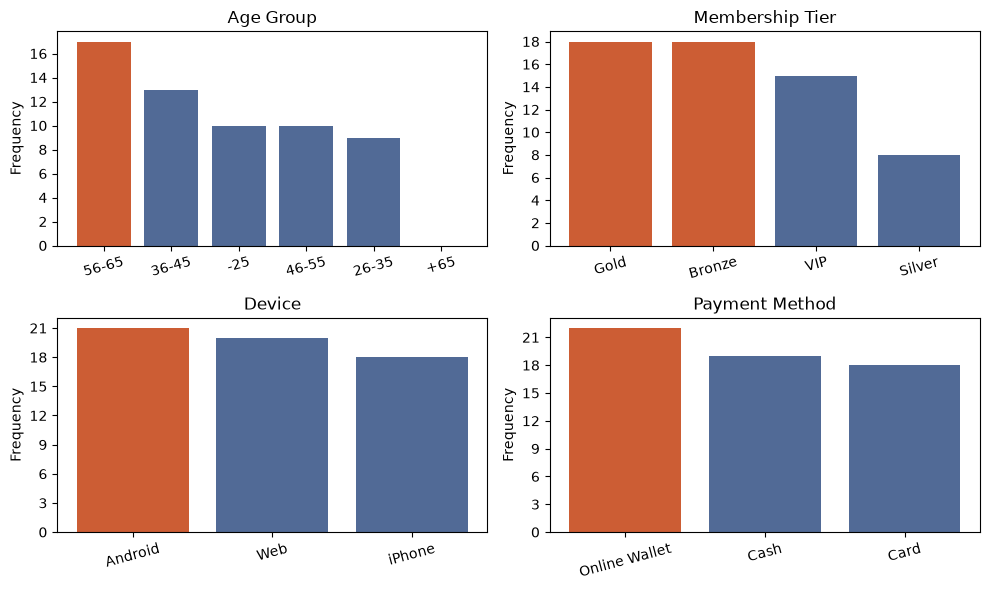

In [255]:
columns = [
    'age_group',
    'membership_tier',
    'device',
    'payment_method'
]

titles = [
    'Age Group',
    'Membership Tier',
    'Device',
    'Payment Method'
]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()  # Make the 2×2 array into a 1D array

for ax, col, title in zip(axes, columns, titles):
    counts = customer_df[col].value_counts()

    colors = ["#516A96"] * len(counts)

    max_count = counts.max()

    for i, value in enumerate(counts.values):
        if value == max_count:
            colors[i] = "#CC5D34"

    ax.bar(
        counts.index, counts.values,
        color=colors,
        linewidth=0.7
    )

    ax.set_title(title)
    ax.set_ylabel('Frequency')
    ax.tick_params(axis='x', rotation=15)

    ax.yaxis.set_major_locator(MaxNLocator(integer=True))


plt.tight_layout()
plt.show()

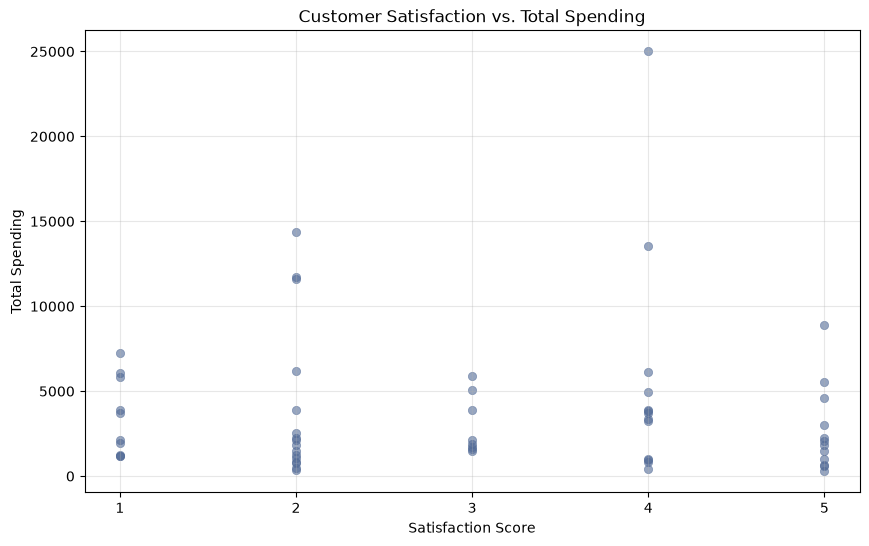

In [256]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_df['satisfaction_score'],
    customer_df['total_spending'],
    alpha=0.6,
    color='#516A96',
    linewidth=0.5
)

plt.xticks([1, 2, 3, 4, 5])
plt.xlim(0.8, 5.2)

plt.xlabel('Satisfaction Score')
plt.ylabel('Total Spending')
plt.title('Customer Satisfaction vs. Total Spending')

plt.grid(alpha=0.3)
plt.show()

### Key Findings

Based on the available data, the dominant customer persona is a middle-aged to older adult, with the largest age group being `54–65 years` (17 customers). Membership distribution does not indicate a single dominant tier, as `Bronze` and `Gold` memberships are equally common, with 18 customers each. Similarly, device usage is fairly balanced, although `Android` is the most frequently used platform (21 customers), followed closely by `Web` (20) and `iPhone` (18). Payment preferences are also relatively evenly distributed, with `online wallets` being the most common method (22 customers), followed by `cash` (19) and `card payments` (18).

***Business Interpretation***


Overall, these distributions do not reveal a clearly distinct customer segment, as the differences between categories are small. From a business perspective, basing the next marketing campaign solely on the largest groups would not be well justified. A more effective strategy would be to first identify which customer segments generate the highest spending, as a smaller but more profitable group may offer better opportunities for targeted marketing and higher return on investment.

## Cities

: Our advertising budget is limited. Identify the province and city that should receive priority. Do not decide using total sales alone; also consider customer count, average spending, purchase behavior, and satisfaction.

In [257]:
city_summary = customer_df.groupby(['city', 'province'], as_index=False).agg(
    customer_count=('customer_id','count'),
    total_revenue=('total_spending','sum'),
    avg_spending=('total_spending','mean'),
    avg_purchase=('purchase_count','mean'),
    median_satisfaction=('satisfaction_score', 'median')
)

### Scoring

In [258]:
factors = ['avg_spending',
           'median_satisfaction',
           'customer_count']

for factor in factors:
    city_summary[factor+'_norm'] = (
        city_summary[factor] - city_summary[factor].min()
    ) / (
        city_summary[factor].max() - city_summary[factor].min()
    )

city_summary['city_score'] = (
    city_summary['avg_spending_norm'] * 0.5 +
    city_summary['median_satisfaction_norm'] * 0.35 +
    city_summary['customer_count_norm'] * 0.25
)

city_summary.drop(
    city_summary[['avg_spending_norm',
                  'median_satisfaction_norm',
                  'customer_count_norm']],
    axis=1, inplace=True)

city_summary

,city,province,customer_count,total_revenue,avg_spending,avg_purchase,median_satisfaction,city_score
0,Ahvaz,Khuzestan,7,23384.78,3340.682857,21.400000,4.0,0.440059
1,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,5.0,0.623029
2,Karaj,Alborz,7,26189.81,3741.401429,16.000000,2.0,0.328489
3,Mashhad,Khorasan,11,64118.44,5828.949091,22.636364,2.0,0.801786
4,Rasht,Gilan,5,15168.54,3033.708000,19.750000,1.0,0.057539
5,Shiraz,Fars,6,20715.92,3452.653333,16.333333,2.0,0.247069
6,Tabriz,East Azerbaijan,12,36192.49,3016.040833,18.600000,3.0,0.479743
7,Tehran,Tehran,6,16021.23,2670.205000,17.166667,2.5,0.166964


### City Charts

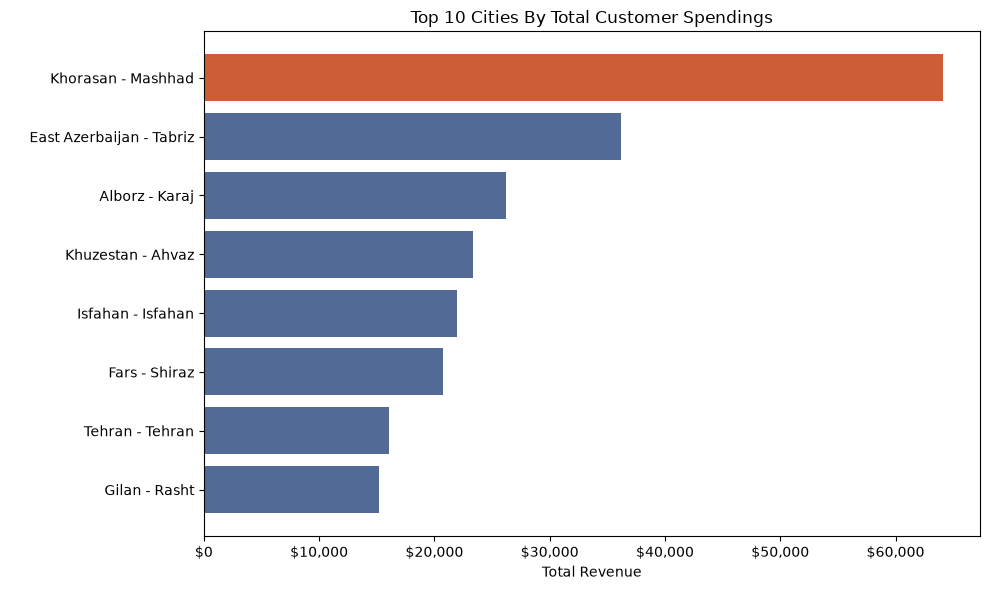

In [259]:
top_cities = city_summary.nlargest(10, 'total_revenue').sort_values('total_revenue')
top_cities_sorted = top_cities.sort_values('total_revenue', ascending=True)
labels = top_cities_sorted['province'] + ' - ' + top_cities_sorted['city']

colors = [
    "#CC5D34" if x == top_cities_sorted['total_revenue'].max() else "#516A96"
    for x in top_cities_sorted['total_revenue']
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    labels,
    top_cities_sorted['total_revenue'],
    color=colors,
    linewidth=0.7
)

ax.set_title('Top 10 Cities By Total Customer Spendings')
ax.set_xlabel('Total Revenue')
ax.set_ylabel(' ')

ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

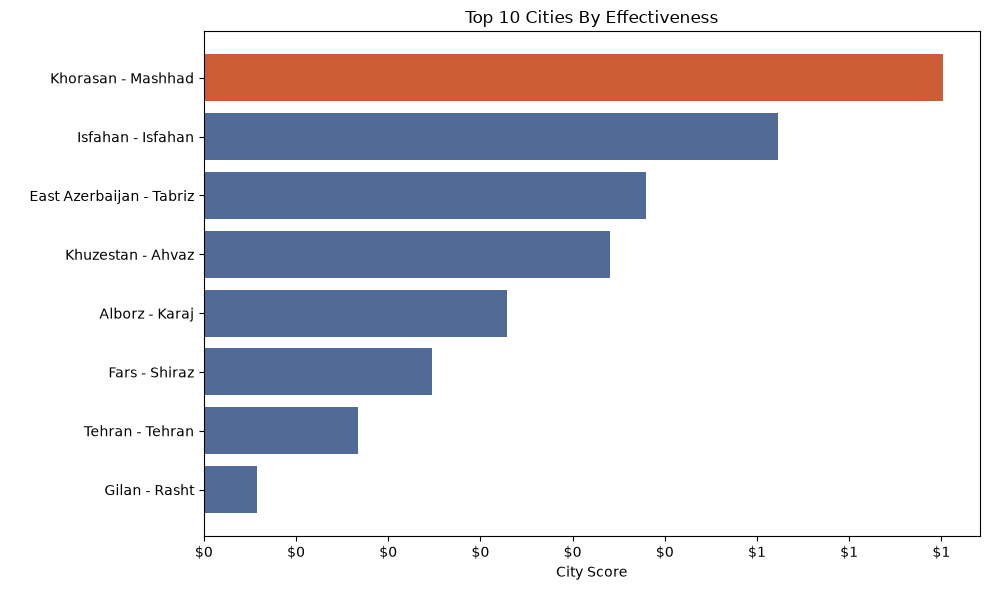

In [260]:
top_cities = city_summary.nlargest(10, 'city_score').sort_values('city_score')
top_cities_sorted = top_cities.sort_values('city_score', ascending=True)
labels = top_cities_sorted['province'] + ' - ' + top_cities_sorted['city']

colors = [
    "#CC5D34" if x == top_cities_sorted['city_score'].max() else "#516A96"
    for x in top_cities_sorted['city_score']
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    labels,
    top_cities_sorted['city_score'],
    color=colors,
    linewidth=0.7
)

ax.set_title('Top 10 Cities By Effectiveness')
ax.set_xlabel('City Score')
ax.set_ylabel(' ')

ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

### Key Findings

`Mashhad` is the recommended city for the next advertising campaign. It achieved the highest weighted score **(0.802)** based on normalized average spending (50%), median satisfaction (35%), and customer count (25%). Its ranking is supported by the highest total revenue (64,118.44), highest average customer spending (5,828.94), and a large customer base, indicating that its performance is not driven by customer count alone. However, its low median satisfaction score (2) suggests that customer experience should be improved alongside marketing efforts to maximize long-term returns.

`Isfahan` and `Tabriz` are both strong alternatives. Isfahan performs well because of its high average spending and excellent customer satisfaction, while Tabriz becomes the stronger alternative when customer count is given greater importance in the scoring model. This sensitivity analysis shows that the preferred alternative depends on the business objective, whereas Mashhad remains the top recommendation under both weighting schemes.

## Customers Loyalty

: We can include only ten customers in the loyalty program. Select customers who combine strong financial value, frequent purchasing, recent activity, and good satisfaction.

In [261]:
loyalty_table = customer_df[['customer_id',
                             'first_name',
                             'purchase_count',
                             'total_spending',
                             'last_purchase_days',
                             'membership_tier',
                             'satisfaction_score']].copy()

factors = ['purchase_count',
           'total_spending',
           'last_purchase_days',
           'satisfaction_score']

for factor in factors:
    loyalty_table[factor+'_norm'] = (
        loyalty_table[factor] - loyalty_table[factor].min()
    ) / (
        loyalty_table[factor].max() - loyalty_table[factor].min()
    )

loyalty_table['last_purchase_days_norm'] = 1 - loyalty_table['last_purchase_days_norm']

loyalty_table['loyalty_score'] = (
    loyalty_table['total_spending_norm'] * 0.4 + # revenue
    loyalty_table['purchase_count_norm'] * 0.3 + # num of purchase
    loyalty_table['last_purchase_days_norm'] * 0.2 + # recency
    loyalty_table['satisfaction_score_norm'] * 0.1 # satisfaction
)

loyalty_table.drop(loyalty_table[['purchase_count_norm',
                                  'total_spending_norm',
                                  'last_purchase_days_norm',
                                  'satisfaction_score_norm']],
                   axis=1, inplace=True)

loyalty_table = loyalty_table.sort_values('loyalty_score', ascending=False, ignore_index=True)

print(f"Median Total Spending: {customer_df['total_spending'].median()}")
print(f"Median Purchase Count: {customer_df['purchase_count'].median()}")

loyalty_table.iloc[:10]

Median Total Spending: 2140.38
Median Purchase Count: 18.0


,customer_id,first_name,purchase_count,total_spending,last_purchase_days,membership_tier,satisfaction_score,loyalty_score
0,1057,Maryam,31.0,13532.74,82,Bronze,4,0.710573
1,1030,Sina,26.0,25000.00,340,VIP,4,0.709400
2,1044,Mina,33.0,14354.34,165,Gold,2,0.645654
3,1059,Ali,31.0,8898.55,224,Gold,5,0.582161
4,1009,Kimia,34.0,11615.42,232,Silver,2,0.573158
5,1004,Sina,23.0,6121.45,40,Gold,4,0.543310
6,1014,Reza,31.0,3353.89,97,VIP,4,0.537640
7,1033,Neda,24.0,5521.20,112,VIP,5,0.527645
8,1012,Arash,27.0,11731.50,224,Gold,2,0.517691
9,1017,Parsa,30.0,3239.40,135,VIP,4,0.505970


In [262]:
loyalty_table.groupby('membership_tier', as_index=False)['loyalty_score'].agg(
    ['count', 'mean', 'median', 'max']
).sort_values('mean', ascending=False)

,membership_tier,count,mean,median,max
3,VIP,14,0.391591,0.394882,0.709400
1,Gold,15,0.390030,0.389918,0.645654
2,Silver,7,0.339023,0.320746,0.573158
0,Bronze,18,0.335276,0.322305,0.710573


### Loyalty Charts

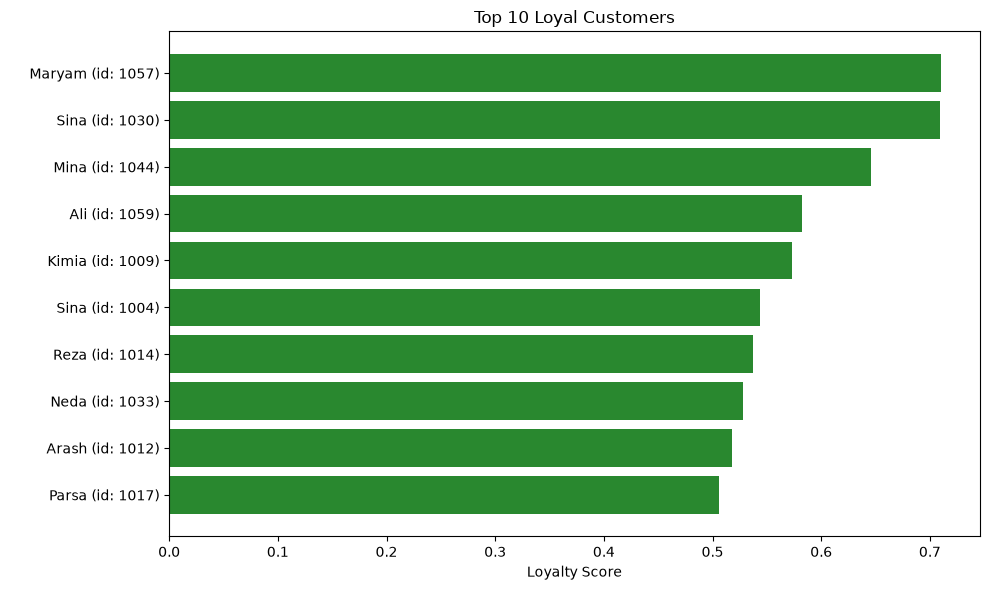

In [263]:
loyalty_table_sorted = loyalty_table.nlargest(10, 'loyalty_score').sort_values('loyalty_score')
labels = (loyalty_table_sorted['first_name'] +
          ' (id: ' +
          loyalty_table_sorted['customer_id'].astype(str) + ')')
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    labels,
    loyalty_table_sorted['loyalty_score'],
    color="#187F1FED",
    linewidth=0.7
)

ax.set_title('Top 10 Loyal Customers')
ax.set_xlabel('Loyalty Score')
ax.set_ylabel(' ')

plt.tight_layout()
plt.show()

### Key Findings

Customers were ranked for the `loyalty program` using a weighted score based on **total spending (40%)**, **purchase count (30%)**, **purchase recency (20%)**, and **customer satisfaction (10%)**, with the weights adjustable to match different business priorities. 

The selected `top 10 customers` all have **purchase counts and total spending above the dataset median**, indicating they are both valuable and actively engaged.

One exception is **Sina (Customer ID: 1030)**, who ranks second due to spending over **$25,000** despite being inactive for **340 days**. This customer may be better suited for a re-engagement campaign than a loyalty reward if recent activity is prioritized. 

Comparing the loyalty scores with the current `membership tiers` doesn't show a strong relationship between membership tier and your loyalty score. However,  **VIP and Gold customers have the highest average loyalty scores**, but the differences between tiers are relatively small, and the **highest individual loyalty score belongs to a Bronze customer**. This suggests that while the current membership program partially reflects customer loyalty, incorporating behavioral metrics such as spending, purchase frequency, and recency could better identify and reward the store's most valuable customers.

## Customers At Risk of Inactivity

: Identify customers who previously created strong value but have not purchased recently. We want to design a reactivation campaign before these customers are completely lost.

In [264]:
customer_cat_df = customer_df[['customer_id',
                               'first_name',
                               'total_spending',
                               'purchase_count',
                               'satisfaction_score',
                               'last_purchase_days']].copy()

customer_cat_df['days_since_signup'] = (
    pd.Timestamp.today() - customer_df['signup_date']
).dt.days

customer_cat_df['high_value_customer'] = (
    customer_cat_df['total_spending'] >=
    customer_cat_df['total_spending'].median()
)

active_threshold = 120

customer_cat_df['inactive'] = (
    customer_cat_df['last_purchase_days'] > active_threshold
)

In [265]:
customer_cat_df['risk_category'] = 'Normal'

customer_cat_df.loc[
    customer_cat_df['high_value_customer'] & customer_cat_df['inactive'],
    'risk_category',
] = 'At Risk'
        

at_risk_df = customer_cat_df[
    customer_cat_df['risk_category'] == 'At Risk'][
        ['customer_id', 'first_name',
         'total_spending',
         'satisfaction_score',
         'purchase_count',
         'last_purchase_days',
         'days_since_signup',
         'risk_category']
].sort_values('total_spending',
              ascending=False,
              ignore_index=True)

print(f"Revenue At Risk: ${at_risk_df['total_spending'].sum():.2f}")
print(f"Number of At Risk Customers: {len(at_risk_df)}")
print(f"Average Spending: ${at_risk_df['total_spending'].mean():.2f}")
print(f"Average Inactivity: {at_risk_df['last_purchase_days'].mean()} days")
print(f"Average Satisfaction: {at_risk_df['satisfaction_score'].mean()}")
print("\n")
print("** High Priority Reactivation List: **")
at_risk_df[at_risk_df['total_spending']>at_risk_df['total_spending'].mean()]

Revenue At Risk: $154884.17
Number of At Risk Customers: 25
Average Spending: $6195.37
Average Inactivity: 233.2 days
Average Satisfaction: 2.68


** High Priority Reactivation List: **


,customer_id,first_name,total_spending,satisfaction_score,purchase_count,last_purchase_days,days_since_signup,risk_category
0,1030,Sina,25000.00,4,26.0,340,517,At Risk
1,1044,Mina,14354.34,2,33.0,165,740,At Risk
2,1012,Arash,11731.50,2,27.0,224,1111,At Risk
3,1009,Kimia,11615.42,2,34.0,232,1910,At Risk
4,1059,Ali,8898.55,5,31.0,224,1066,At Risk
5,1010,Arash,7241.47,1,19.0,276,1503,At Risk
6,1050,Reza,6198.00,2,30.0,205,1098,At Risk


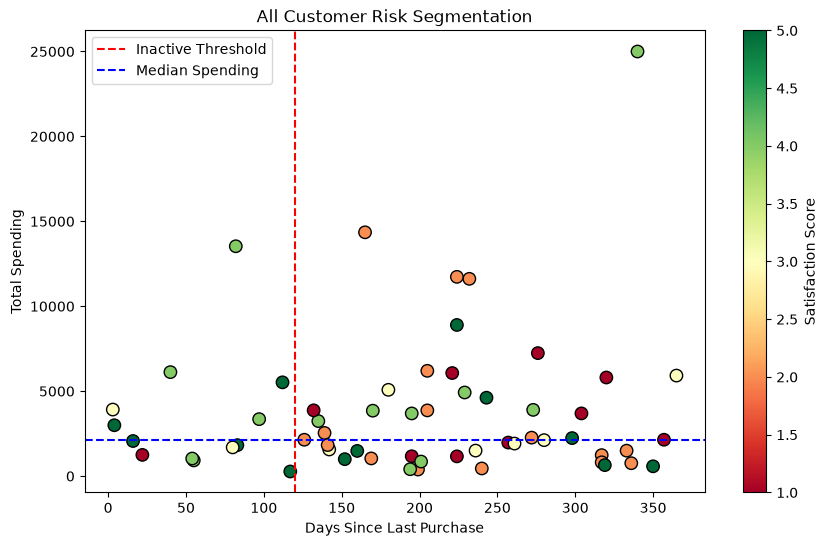

In [266]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    customer_cat_df['last_purchase_days'],
    customer_cat_df['total_spending'],
    c=customer_cat_df['satisfaction_score'],
    cmap='RdYlGn',      # Red → Yellow → Green
    s=80,
    edgecolor='black'
)

plt.colorbar(scatter, label='Satisfaction Score')

ax.axvline(active_threshold, color='red', linestyle='--', label='Inactive Threshold')
ax.axhline(customer_cat_df['total_spending'].median(),
           color='blue',
           linestyle='--',
           label='Median Spending')

ax.set_xlabel('Days Since Last Purchase')
ax.set_ylabel('Total Spending')
ax.set_title('All Customer Risk Segmentation')
ax.legend()

plt.show()

### Key Findings

A `valuable customer at risk` is a customer with high historical spending and/or frequent purchases who has been inactive for a long period (e.g., more than 120 days). Customer satisfaction is then used to distinguish between customers who may have left due to dissatisfaction and those who are simply inactive.

**Revenue at risk** due to these customers inactivity is $154884.17.
**Number of at risk customers** is 25.
**Average satisfaction** of inactive customers is 2.68.

For inactive customers with `low satisfaction` (satisfaction score: 1-2), contact them with a personalized apology, request feedback, investigate potential service issues, and provide a recovery incentive (discount, voucher, free shipping).

For the customers who were `previously satisfied` (satisfaction score: 4-5) but have not purchased recently. Send personalized product recommendations, loyalty rewards, or limited-time offers to encourage them to return.

## Discount

In [267]:
discount_df = customer_df.groupby('discount_used', as_index=False).agg(
    sample_size = ('customer_id', 'count'),
    avg_spending = ('total_spending', 'mean'),
    total_spending = ('total_spending', 'sum'),
    purchase_count = ('purchase_count', 'sum'),
    returned_items = ('returned_items', 'median'),
    satisfaction = ('satisfaction_score', 'median')
)

discount_df

,discount_used,sample_size,avg_spending,total_spending,purchase_count,returned_items,satisfaction
0,0,33,3849.975758,127049.20,584.0,4.0,3.0
1,1,26,3719.897308,96717.33,449.0,3.0,3.5


### Discount Charts

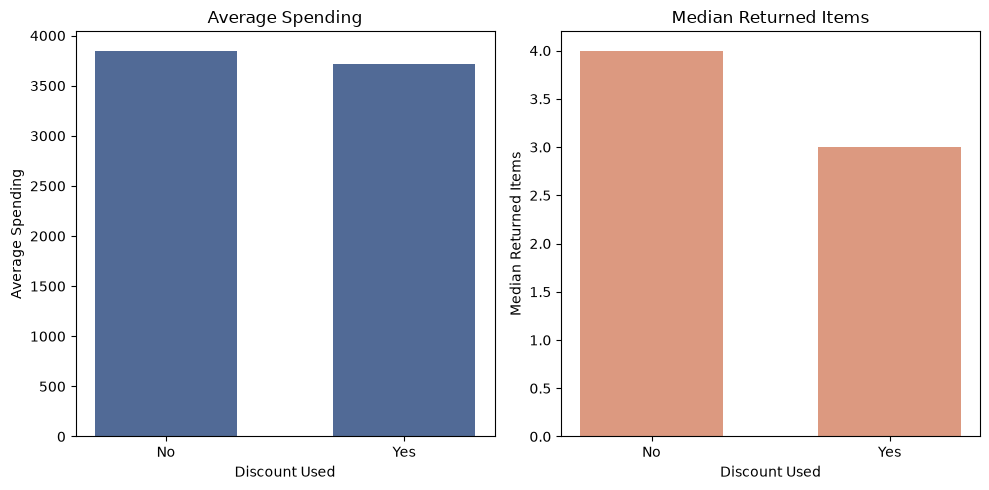

In [268]:
discount_df['discount_used'] = discount_df['discount_used'].map({
    0: 'No',
    1: 'Yes'
})

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Average spending
axes[0].bar(
    discount_df['discount_used'],
    discount_df['avg_spending'],
    width=0.6,
    color="#516A96"
)

axes[0].set_title('Average Spending')
axes[0].set_xlabel('Discount Used')
axes[0].set_ylabel('Average Spending')

# Median returned items
axes[1].bar(
    discount_df['discount_used'],
    discount_df['returned_items'],
    width=0.6,
    color="#DC9980"
)

axes[1].set_title('Median Returned Items')
axes[1].set_xlabel('Discount Used')
axes[1].set_ylabel('Median Returned Items')

plt.tight_layout()
plt.show()

### Key Findings

Customers who **did not use discounts** `spent` slightly more on average (**$3,850** vs. **$3,720**) and `purchased` more items overall, while discount users showed a slightly higher median satisfaction score (**3.5** vs. **3.0**). The median number of `returned items` was similar between the two groups, 3 for discount users and 4 for not discount users. 

The comparison includes **33 customers without discounts** and **26 customers with discounts**, making the group sizes reasonably balanced.

## Payment Method / Device

In [269]:
payment_df = customer_df.groupby('payment_method', as_index=False).agg(
    sample_size = ('customer_id', 'count'),
    avg_spending = ('total_spending', 'mean'),
    total_spending = ('total_spending', 'sum')
)

payment_df

,payment_method,sample_size,avg_spending,total_spending
0,Card,18,3976.779444,71582.03
1,Cash,19,4251.677368,80781.87
2,Online Wallet,22,3245.574091,71402.63


In [270]:
device_df = customer_df.groupby('device', as_index=False).agg(
    sample_size = ('customer_id', 'count'),
    avg_spending = ('total_spending', 'mean'),
    total_spending = ('total_spending', 'sum')
)

device_df

,device,sample_size,avg_spending,total_spending
0,Android,21,3664.73619,76959.46
1,Web,20,3943.80300,78876.06
2,iPhone,18,3773.94500,67931.01


### Payment Method / Device Charts

In [271]:
pay_color = {
    'Card': "#516A96",
    'Online Wallet': "#7A92BF",
    'Cash': "#DC9980"
}

device_color = {
    'Android': "#516A96",
    'Web': "#7A92BF",
    'iPhone': "#DC9980"
}

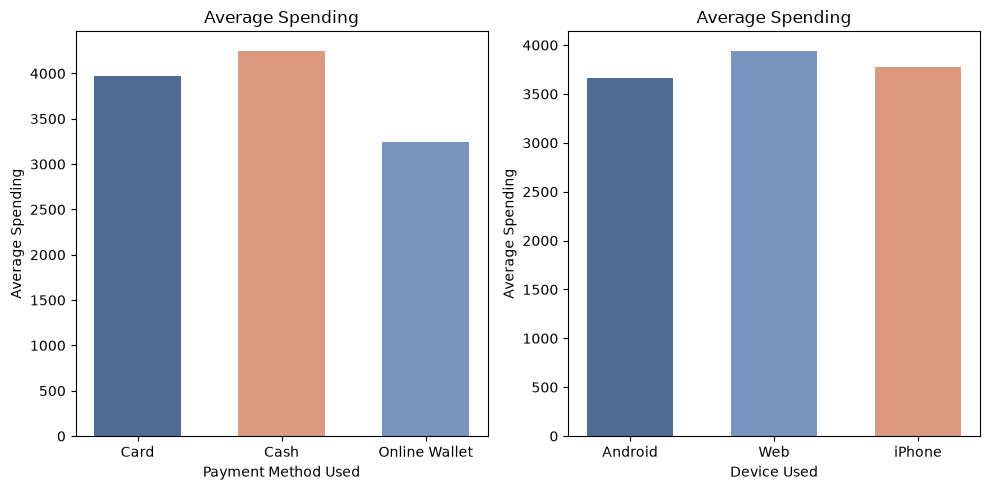

In [272]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# payment
axes[0].bar(
    payment_df['payment_method'],
    payment_df['avg_spending'],
    width=0.6,
    color= [pay_color[p] for p in payment_df['payment_method']]
)

axes[0].set_title('Average Spending')
axes[0].set_xlabel('Payment Method Used')
axes[0].set_ylabel('Average Spending')

# device
axes[1].bar(
    device_df['device'],
    device_df['avg_spending'],
    width=0.6,
    color= [device_color[p] for p in device_df['device']]
)

axes[1].set_title('Average Spending')
axes[1].set_xlabel('Device Used')
axes[1].set_ylabel('Average Spending')

plt.tight_layout()
plt.show()

### Key Findings

Among payment methods, **Cash** customers had the highest `average spending` (**$4,252**), while **Web** users had the highest average spending among device types (**$3,944**). Since the `sample sizes` for payment methods (18–22 customers) and devices (18–21 customers) are similar, these results provide a reasonable basis for business decisions. **However, this analysis identifies associations only and does not establish a causal relationship between discount use, payment method, device type, and customer spending or satisfaction.**